In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB

In [3]:
from src.affinity import AffinityInputConfig, build_affinity_matrix
from src.build_wh import (
    build_location_grid,
    build_location_costs,
    build_location_distance_matrix,
    build_product_frequency,
)

In [4]:
DATA_DIR = PROJECT_ROOT / "data" / "synthetic_dataset"

products_df = pd.read_csv(DATA_DIR / "products.csv")
orders_df = pd.read_csv(DATA_DIR / "orders.csv")
order_lines_df = pd.read_csv(DATA_DIR / "order_lines.csv")

print(products_df.shape, orders_df.shape, order_lines_df.shape)
products_df.head()

(100, 4) (5000, 3) (19995, 4)


,product_id,product_name,group_ids,is_popular
0,0,P000,0,0
1,1,P001,3,0
2,2,P002,3,0
3,3,P003,2,0
4,4,P004,2,0


In [5]:
affinity_config = AffinityInputConfig(
    order_col="order_id",
    product_col="product_id",
    drop_duplicate_lines=True,
    zero_diagonal=True,
)

A_full, product_ids = build_affinity_matrix(
    method="cooccurrence",
    order_lines=order_lines_df,
    config=affinity_config,
)

freq_series = build_product_frequency(order_lines_df)
f_full = freq_series.reindex(product_ids, fill_value=0.0).to_numpy(dtype=float)

print(A_full.shape, f_full.shape)

(100, 100) (100,)


In [6]:
n_products = len(product_ids)

n_rows = 12
n_cols = 12

grid = build_location_grid(n_rows, n_cols)
location_ids = grid["location_id"].to_numpy(dtype=int)

c_full = build_location_costs(n_rows, n_cols) + 1.0
D_full = build_location_distance_matrix(n_rows, n_cols)

n_locations = len(location_ids)

print("Products:", n_products)
print("Locations:", n_locations)

Products: 100
Locations: 144


In [7]:
freq_rank = pd.Series(f_full).rank(method="dense", ascending=False).to_numpy()

q_full = np.ones(n_products, dtype=int)

q_full[f_full >= np.quantile(f_full, 0.90)] = 3
q_full[(f_full >= np.quantile(f_full, 0.70)) & (f_full < np.quantile(f_full, 0.90))] = 2

print("Total required slots:", q_full.sum())
print("Available locations:", n_locations)

assert q_full.sum() <= n_locations, "No alcanzan las ubicaciones para los slots requeridos."

Total required slots: 140
Available locations: 144


In [8]:
df_q = pd.DataFrame(
    {
        "product_id": product_ids,
        "frequency": f_full,
        "q_slots": q_full,
    }
).sort_values(["q_slots", "frequency"], ascending=[False, False])

df_q.head(20)

,product_id,frequency,q_slots
99,99,376.0,3
22,22,369.0,3
31,31,365.0,3
75,75,361.0,3
95,95,342.0,3
25,25,336.0,3
61,61,323.0,3
69,69,316.0,3
10,10,315.0,3
91,91,313.0,3


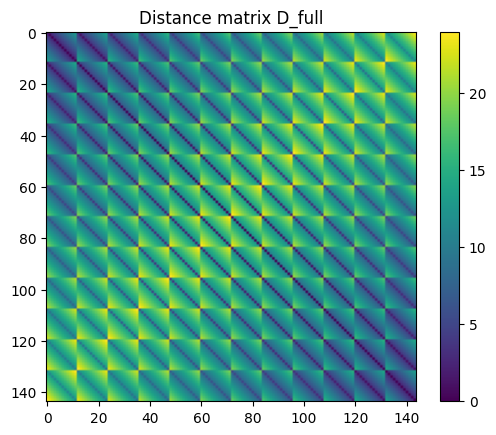

In [9]:
plt.imshow(D_full)
plt.colorbar()
plt.title("Distance matrix D_full")
plt.show()

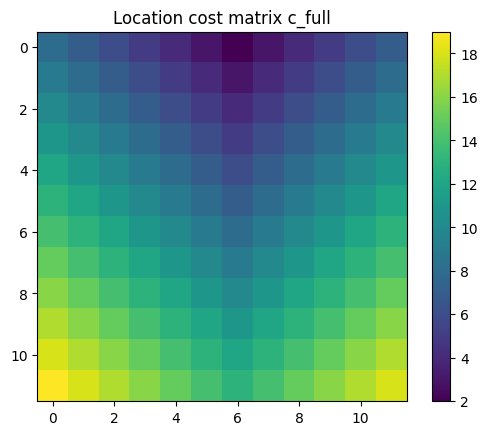

In [10]:
cost_matrix = grid.assign(cost=c_full).pivot(index="row", columns="col", values="cost")

plt.imshow(cost_matrix)
plt.colorbar()
plt.title("Location cost matrix c_full")
plt.show()

In [11]:
I = range(n_products)
K = range(n_locations)

lambda_weight = 0.5

In [12]:
os.environ["GRB_WLSACCESSID"] = "8f50bd08-d0fd-427d-aaab-c81b8ea6d04b"
os.environ["GRB_WLSSECRET"] = "bdba46fa-deda-4a94-85ff-fc272bf7e78d"
os.environ["GRB_LICENSEID"] = "2805866"

In [13]:
assert os.getenv("GRB_WLSACCESSID") is not None
assert os.getenv("GRB_WLSSECRET") is not None
assert os.getenv("GRB_LICENSEID") is not None

In [14]:
m = gp.Model("full_general_slotting")

m.Params.TimeLimit = 1800
m.Params.MIPGap = 0.02
m.Params.OutputFlag = 1

Restricted license - for non-production use only - expires 2027-11-29
Set parameter TimeLimit to value 1800
Set parameter MIPGap to value 0.02
Set parameter OutputFlag to value 1


In [15]:
x = m.addVars(
    [(i, k) for i in I for k in K],
    vtype=GRB.BINARY,
    name="x"
)
# cada producto usa q_i ubicaciones
for i in I:
    m.addConstr(
        gp.quicksum(x[i, k] for k in K) == int(q_full[i]),
        name=f"assign_product_{i}"
    )

# cada ubicacion en a lo sumo 1 producto
for k in K:
    m.addConstr(
        gp.quicksum(x[i, k] for i in I) <= 1,
        name=f"capacity_location_{k}"
    )

In [16]:
linear_term = gp.quicksum(
    f_full[i] * c_full[k] * x[i, k]
    for i in I
    for k in K
)

quadratic_term = gp.quicksum(
    (A_full[i, j] / (q_full[i] * q_full[j])) * D_full[k, l] * x[i, k] * x[j, l]
    for i in I
    for j in range(i + 1, n_products)
    for k in K
    for l in K
)

In [17]:
m.setObjective(
    lambda_weight * linear_term
    + (1 - lambda_weight) * quadratic_term,
    GRB.MINIMIZE
)

In [18]:
m.optimize()

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 10.0 (19045.2))

CPU model: AMD Ryzen 7 5700G with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Non-default parameters:
TimeLimit  1800
MIPGap  0.02



GurobiError: Model too large for size-limited license; visit https://gurobi.com/unrestricted for more information

In [ ]:
print("Status:", m.Status)
print("Runtime:", m.Runtime)
print("ObjVal:", m.ObjVal if m.SolCount > 0 else None)
print("MIPGap:", m.MIPGap if m.SolCount > 0 else None)

In [ ]:
solution_rows = []

if m.SolCount > 0:
    for i in I:
        for k in K:
            if x[i, k].X > 0.5:
                solution_rows.append(
                    {
                        "product_idx": i,
                        "product_id": product_ids[i],
                        "location_id": location_ids[k],
                        "frequency": f_full[i],
                        "q_slots": q_full[i],
                        "location_cost": c_full[k],
                    }
                )

df_solution = pd.DataFrame(solution_rows)
df_solution.head()

In [ ]:
df_solution = df_solution.merge(
    grid[["location_id", "row", "col"]],
    on="location_id",
    how="left",
)

df_solution.sort_values(["product_id", "row", "col"]).head(30)

In [ ]:
solution_grid = grid.merge(
    df_solution.groupby("location_id")["product_id"].first().reset_index(),
    on="location_id",
    how="left",
)

solution_grid["label"] = solution_grid["product_id"].fillna(-1).astype(int)

solution_grid.pivot(index="row", columns="col", values="label")

In [ ]:
# Chequeo de cuántos slots recibió cada producto.
assigned_slots = (
    df_solution.groupby("product_id")
    .size()
    .rename("assigned_slots")
    .reset_index()
)

check_slots = (
    pd.DataFrame({"product_id": product_ids, "q_slots": q_full})
    .merge(assigned_slots, on="product_id", how="left")
    .fillna({"assigned_slots": 0})
)

check_slots.head(20)

In [ ]:
check_slots["ok"] = check_slots["q_slots"] == check_slots["assigned_slots"]
check_slots["ok"].value_counts()

In [ ]:
# Productos más frecuentes y dónde quedaron.
top_products = (
    pd.DataFrame({"product_id": product_ids, "frequency": f_full, "q_slots": q_full})
    .sort_values("frequency", ascending=False)
    .head(15)
)

top_solution = df_solution.merge(top_products, on="product_id", suffixes=("", "_prod"))
top_solution.sort_values(["frequency_prod", "product_id", "row", "col"], ascending=[False, True, True, True])